In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.neural_network import MLPClassifier


In [2]:
data_path = "../../data/Student_performance_data _.csv"
df = pd.read_csv(data_path)
print(df.columns.tolist())


['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [3]:
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df["GradeClass"].value_counts())


   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [4]:
target_col = "GradeClass"
drop_cols = ["StudentID"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())


X shape: (2392, 13)
y shape: (2392,)
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  
0  2.929196  
1  3.042915  
2

In [5]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
print("Target classes:", label_enc.classes_)


Target classes: [0. 1. 2. 3. 4.]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1913, 13)
Test shape: (479, 13)


In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Categorical features: []


In [8]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", MLPClassifier(max_iter=500, random_state=42,
                                  early_stopping=True, n_iter_no_change=20))
])

In [9]:

param_grid = {
    "feature_selection__k": [3, 5, 7, "all"],
    "classifier__hidden_layer_sizes": [(64, 32), (128, 64, 32)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.01],
    "classifier__max_iter": [200, 400],   
}


In [10]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV F1 Macro:", grid_search.best_score_)


Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best Parameters:
{'classifier__activation': 'tanh', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (128, 64, 32), 'classifier__learning_rate_init': 0.001, 'classifier__max_iter': 200, 'feature_selection__k': 3}

Best CV F1 Macro: 0.8631813311976833


In [11]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)


In [12]:
from copy import deepcopy


best_params    = grid_search.best_params_
best_k         = best_params["feature_selection__k"]
best_hidden    = best_params["classifier__hidden_layer_sizes"]
best_act       = best_params["classifier__activation"]
best_alpha     = best_params["classifier__alpha"]
best_lr        = best_params["classifier__learning_rate_init"]
best_epochs    = best_params["classifier__max_iter"]   # max epochs

print("Re-training with best params for epoch visualisation:")
print(f"  Architecture : {best_hidden}")
print(f"  Activation   : {best_act}")
print(f"  Alpha        : {best_alpha}")
print(f"  LR init      : {best_lr}")
print(f"  Max epochs   : {best_epochs}")
print(f"  Feature k    : {best_k}")


mlp_epoch = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    activation=best_act,
    alpha=best_alpha,
    learning_rate_init=best_lr,
    max_iter=best_epochs,
    random_state=42,
    early_stopping=True,     
    validation_fraction=0.1,
    n_iter_no_change=20,      # stop when val score stalls for 20 epochs
    tol=1e-4,
)

epoch_pipeline = Pipeline(steps=[
    ("preprocessor",     deepcopy(preprocessor)),
    ("feature_selection", SelectKBest(score_func=f_classif, k=best_k)),
    ("classifier",       mlp_epoch),
])

epoch_pipeline.fit(X_train, y_train)

loss_curve        = mlp_epoch.loss_curve_          
validation_scores = mlp_epoch.validation_scores_  
n_epochs          = len(loss_curve)

print(f"\nTraining converged in {n_epochs} epochs (early stopping)")


Re-training with best params for epoch visualisation:
  Architecture : (128, 64, 32)
  Activation   : tanh
  Alpha        : 0.0001
  LR init      : 0.001
  Max epochs   : 200
  Feature k    : 3

Training converged in 62 epochs (early stopping)


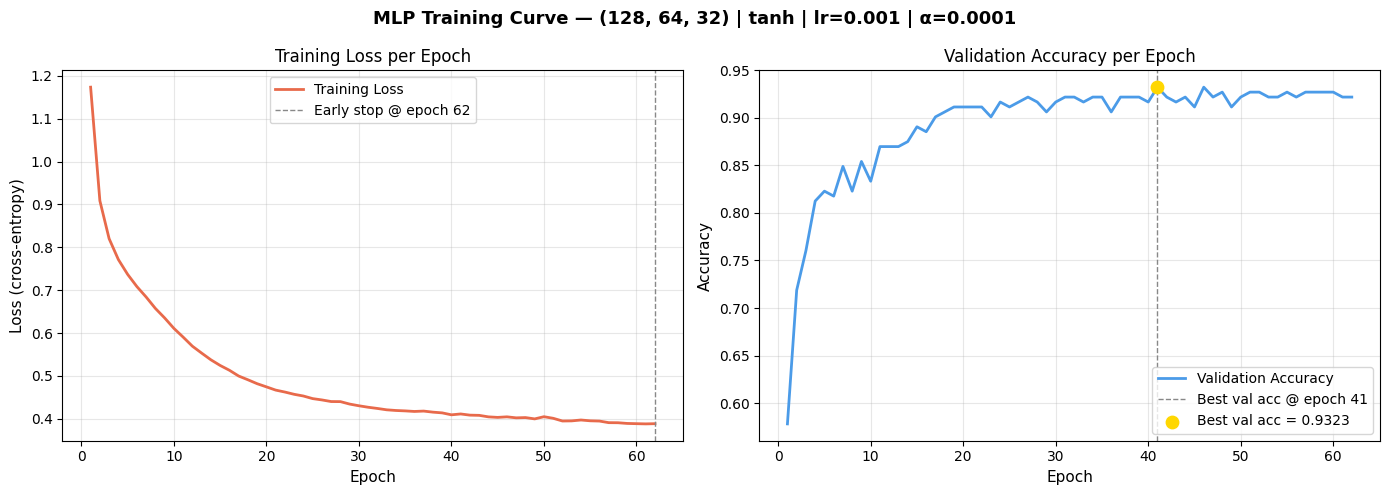

Training curve saved → visualizations/neural_network_training_curve.png


In [13]:

epochs_range = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"MLP Training Curve — {best_hidden} | {best_act} | lr={best_lr} | α={best_alpha}",
    fontsize=13, fontweight="bold"
)


axes[0].plot(epochs_range, loss_curve, color="#E86A4B", linewidth=2, label="Training Loss")
axes[0].axvline(n_epochs, color="#888", linestyle="--", linewidth=1,
                label=f"Early stop @ epoch {n_epochs}")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss (cross-entropy)", fontsize=11)
axes[0].set_title("Training Loss per Epoch", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(epochs_range, validation_scores, color="#4B9BE8", linewidth=2,
             label="Validation Accuracy")
best_val_epoch = int(np.argmax(validation_scores)) + 1
best_val_score = max(validation_scores)
axes[1].axvline(best_val_epoch, color="#888", linestyle="--", linewidth=1,
                label=f"Best val acc @ epoch {best_val_epoch}")
axes[1].scatter([best_val_epoch], [best_val_score], color="gold",
                zorder=5, s=80, label=f"Best val acc = {best_val_score:.4f}")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_title("Validation Accuracy per Epoch", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../../visualizations", exist_ok=True)
plt.savefig("../../visualizations/neural_network_training_curve.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Training curve saved → visualizations/neural_network_training_curve.png")


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Test Metrics - Neural Network (MLP):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_enc.classes_]))


Test Metrics - Neural Network (MLP):
Accuracy: 0.9123
Precision (macro): 0.8980
Recall (macro): 0.8230
F1-score (macro): 0.8468

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.48      0.62        21
         1.0       0.86      0.89      0.87        54
         2.0       0.90      0.92      0.91        78
         3.0       0.89      0.86      0.87        83
         4.0       0.94      0.97      0.95       243

    accuracy                           0.91       479
   macro avg       0.90      0.82      0.85       479
weighted avg       0.91      0.91      0.91       479



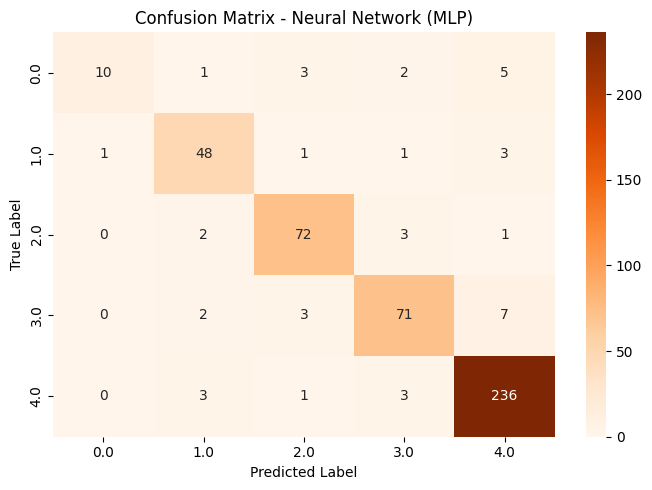

In [15]:
cm = confusion_matrix(y_test, y_pred)
os.makedirs("../../visualizations", exist_ok=True)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title("Confusion Matrix - Neural Network (MLP)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../../visualizations/neural_network_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
results_df = pd.DataFrame({
    "Model": ["Neural Network (MLP)"],
    "Best_Params": [str(grid_search.best_params_)],
    "CV_F1_Macro": [grid_search.best_score_],
    "Test_Accuracy": [accuracy],
    "Test_Precision_Macro": [precision],
    "Test_Recall_Macro": [recall],
    "Test_F1_Macro": [f1]
})
os.makedirs("../../results", exist_ok=True)
results_df.to_csv("../../results/neural_network_results.csv", index=False)
print("Results saved to ../../results/neural_network_results.csv")


Results saved to ../../results/neural_network_results.csv
